<a target="_blank" href="https://colab.research.google.com/github/lukebarousse/Python_Data_Analytics_Course/blob/main/4_Problems/2_15_Matplotlib Scatter Plots.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

README.md:   0%|          | 0.00/3.25k [00:00<?, ?B/s]

data_jobs.csv:   0%|          | 0.00/231M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/785741 [00:00<?, ? examples/s]

## 🟨 Median Yearly Salary vs. Job Count (2.15.1)

In [14]:
df
job_count = df['job_title_short'].value_counts().reset_index()
job_count
job_median_salary=df.groupby('job_title_short')['salary_year_avg'].median().reset_index()
job_median_salary.rename(columns={'salary_year_avg':'median_salary'}, inplace=True)
job_median_salary
df_mer=pd.merge(job_count, job_median_salary, on='job_title_short')
df_mer

,job_title_short,count,median_salary
0,Data Analyst,196075,90000.0
1,Data Engineer,186241,125000.0
2,Data Scientist,172286,127500.0
3,Business Analyst,49063,85000.0
4,Software Engineer,44929,99150.0
5,Senior Data Engineer,44563,147500.0
6,Senior Data Scientist,36957,155500.0
7,Senior Data Analyst,29216,111175.0
8,Machine Learning Engineer,14080,106415.0
9,Cloud Engineer,12331,90000.0


Text(0.5, 1.0, 'Median Yearly Salary vs. Job Count')

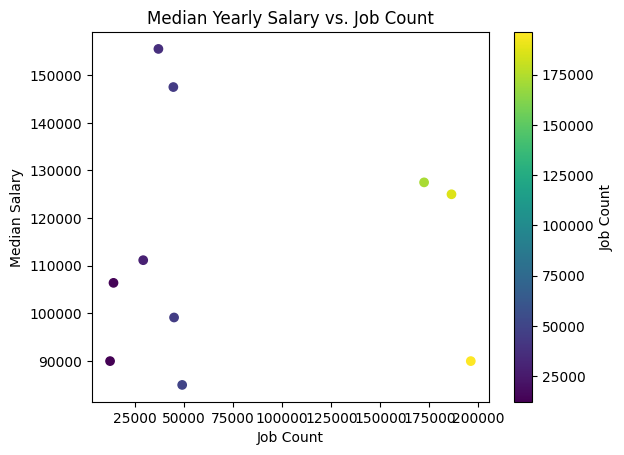

In [19]:
plt.scatter(df_mer['count'],df_mer['median_salary'],cmap='viridis' ,c=df_mer['count'])
plt.colorbar(label='Job Count')
plt.xlabel('Job Count')
plt.ylabel('Median Salary')
plt.title('Median Yearly Salary vs. Job Count')

---

## 🟨 Top 7 Countries by Median Yearly Salary vs Job Count  (2.15.2)

In [21]:
df

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,NaN,NaN,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,None,NaN,NaN,Kristina Daniel,"[bash, python, oracle, aws, ansible, puppet, j...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,None,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"[bash, python, perl, linux, unix, kubernetes, ...","{'os': ['linux', 'unix'], 'other': ['kubernete..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,None,NaN,NaN,HABA FAMILYGROUP,"[sas, sas, sql, excel]","{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,None,NaN,NaN,Lendlease Corporation,"[powerpoint, excel]","{'analyst_tools': ['powerpoint', 'excel']}"
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,None,NaN,NaN,Capital One,"[python, go, nosql, sql, mongo, shell, mysql, ...","{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."


Text(0, 0.5, 'Median Salary')

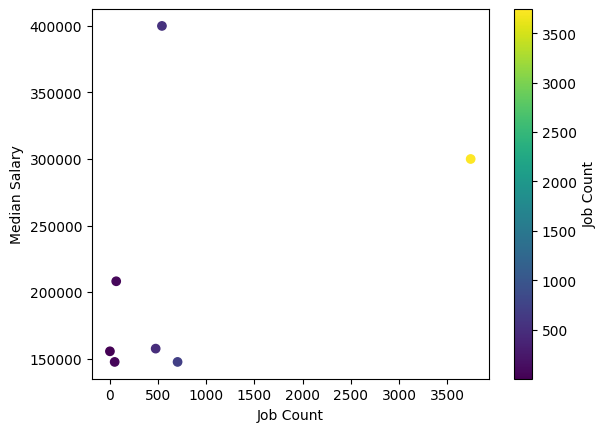

In [38]:
salary = df.groupby('job_country')['salary_year_avg'].median().sort_values(ascending=False).head(7).reset_index()
salary.rename(columns={'salary_year_avg':'median_salary'}, inplace=True)
jobcount = df['job_country'].value_counts()
new_p = pd.merge(salary, jobcount, on='job_country' , how='inner')
plt.scatter(new_p['count'],new_p['median_salary'],cmap='viridis' ,c=new_p['count'])
plt.colorbar(label='Job Count')
plt.xlabel('Job Count')
plt.ylabel('Median Salary')




---

## 🟥 Average Yearly Salary vs. Job Count for Top Roles by Schedule Type (2.15.3)

In [41]:
# Code Needed
target_job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

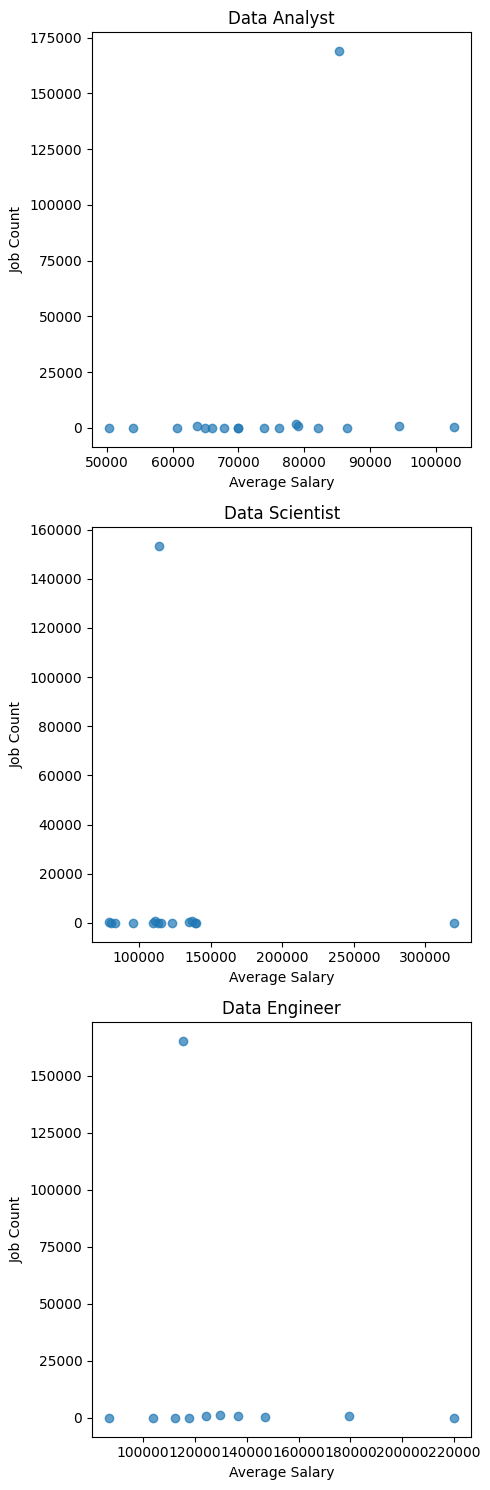

In [54]:
fig, ax = plt.subplots(len(target_job_titles),1,figsize=(5,15))

for i,job_title in enumerate(target_job_titles):
    df_new = df[df['job_title_short'] == job_title]
    avg_salry = df_new.groupby('job_schedule_type')['salary_year_avg'].mean()
    job_here = df_new['job_schedule_type'].value_counts()
    ax[i].scatter(avg_salry,job_here,alpha=0.7)
    ax[i].set_title(job_title)
    ax[i].set_xlabel('Average Salary')
    ax[i].set_ylabel('Job Count')

plt.tight_layout()

---